# Phase 1 - Cross-annotation convergence + viability decomposition (Colab)

**Aim 1 + H0 of the in silico convergence protocol.** Measure how much functionally unrelated perturbations resemble each other transcriptionally (against a control-calibrated null), then strip out the generic distress / viability axis and re-measure - the residual is the mechanism-specific signal.

This notebook is self-contained; run the cells top to bottom.

1. **Setup** installs the one extra dependency (AnnData).
2. **Library** cells define the gene sets, the convergence metric, the H0 decomposition, a synthetic-data generator, and the runner.
3. **Synthetic validation** runs the pipeline on data with a *known* planted answer - it should report ~80% of convergence as viability, a surviving residual, and `PASS = True`.
4. **Real data** runs the identical analysis on the Replogle atlas (Colab has full internet, so you can download it here or mount Drive).

> The code mirrors the repo's `src/*.py` modules, consolidated into one notebook because Colab notebooks each get a fresh runtime and do not import one another.

## 1. Setup

In [1]:
# Colab ships numpy, pandas, scipy, scikit-learn, statsmodels and matplotlib.
# AnnData is the only extra dependency Phase 1 needs.
!pip install -q anndata
%matplotlib inline

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## 2. Library - definitions
The next five cells define everything. They mirror `gene_sets.py`, `convergence.py`, `viability.py`, `simulate.py`, and the runner.

### 2.1 Gene sets (`gene_sets.py`)

In [2]:
"""
gene_sets.py
============
Curated gene sets used by the Phase 1 pipeline.

- The VIABILITY signature (cell-cycle proliferation + death/stress) is what H0
  regresses out: it captures the generic "sick / dividing cell" axis that makes
  functionally unrelated perturbations look alike for reasons that are NOT
  mechanism-specific.
- The ISR_ATF4 set is NOT regressed out in H0. It is included so the residual
  convergence (the part that survives viability regression) can be interpreted,
  and it is the anchor for H1 in a later phase.

Cell-cycle lists are the widely used Tirosh et al. (2016) / Seurat `cc.genes`
S-phase and G2M lists. A handful of symbols use legacy names (e.g. MLF1IP=CENPU,
FAM64A=PIMREG, HN1=JPT1); update aliases when applying to real data with a
symbol-mapping step. For the synthetic validation the literal symbols are used.
"""

CELL_CYCLE_S = [
    "MCM5", "PCNA", "TYMS", "FEN1", "MCM2", "MCM4", "RRM1", "UNG", "GINS2",
    "MCM6", "CDCA7", "DTL", "PRIM1", "UHRF1", "MLF1IP", "HELLS", "RFC2",
    "RPA2", "NASP", "RAD51AP1", "GMNN", "WDR76", "SLBP", "CCNE2", "UBR7",
    "POLD3", "MSH2", "ATAD2", "RAD51", "RRM2", "CDC45", "CDC6", "EXO1",
    "TIPIN", "DSCC1", "BLM", "CASP8AP2", "USP1", "CLSPN", "POLA1", "CHAF1B",
    "BRIP1", "E2F8",
]

CELL_CYCLE_G2M = [
    "HMGB2", "CDK1", "NUSAP1", "UBE2C", "BIRC5", "TPX2", "TOP2A", "NDC80",
    "CKS2", "NUF2", "CKS1B", "MKI67", "TMPO", "CENPF", "TACC3", "FAM64A",
    "SMC4", "CCNB2", "CKAP2L", "CKAP2", "AURKB", "BUB1", "KIF11", "ANP32E",
    "TUBB4B", "GTSE1", "KIF20B", "HJURP", "CDCA3", "HN1", "CDC20", "TTK",
    "CDC25C", "KIF2C", "RANGAP1", "NCAPD2", "DLGAP5", "CDCA2", "CDCA8",
    "ECT2", "KIF23", "HMMR", "AURKA", "PSRC1", "ANLN", "LBR", "CKAP5",
    "CENPE", "CTCF", "NEK2", "G2E3", "GAS2L3", "CBX5", "CENPA",
]

# Generic apoptosis / cellular-stress markers (the "death" half of the
# viability axis). Kept distinct from the ISR set below where possible.
DEATH_STRESS = [
    "GADD45A", "GADD45B", "PMAIP1", "BBC3", "BAX", "BAK1", "CASP3", "CASP7",
    "CDKN1A", "MDM2", "TP53I3", "BTG2", "PLK3", "FAS", "TNFRSF10B", "GDF15",
]

# Integrated stress response / ATF4 program. NOT regressed in H0.
# Used to interpret the residual convergence and as the H1 anchor.
ISR_ATF4 = [
    "ATF4", "DDIT3", "TRIB3", "ASNS", "PSAT1", "PHGDH", "SLC7A11", "ATF3",
    "CEBPB", "CEBPG", "CHAC1", "DDIT4", "STC2", "VEGFA", "MTHFD2", "SHMT2",
    "ALDH18A1", "WARS", "SARS", "CTH",
]

# The viability signature regressed out in H0.
VIABILITY_SIGNATURE = CELL_CYCLE_S + CELL_CYCLE_G2M + DEATH_STRESS


def available(symbols, var_names):
    """Return the subset of `symbols` present in `var_names` (an iterable)."""
    s = set(var_names)
    return [g for g in symbols if g in s]

### 2.2 Aim 1 - convergence metric (`convergence.py`)

In [3]:
"""
convergence.py
==============
Aim 1: quantify cross-annotation transcriptomic convergence.

Definitions
-----------
- A perturbation is represented by its pseudobulk, per-gene z-normalized
  expression profile (a vector over genes). This matches the Replogle et al.
  2022 "gemgroup Z-normalized pseudo-bulk" representation.
- Convergence between two perturbations = Pearson correlation of their profiles
  across a fixed feature-gene set (the Replogle convention).
- The calibrated null is the distribution of profile correlations among
  non-targeting control "pseudo-perturbations". All convergence is reported
  RELATIVE to this null (a raw correlation means nothing without it).
- Cross-annotation convergence = convergence restricted to perturbation pairs in
  *different* annotation groups (a placeholder for the stricter GO/CORUM/STRING
  orthogonality filter built in a later phase). Within-annotation convergence is
  reported alongside as the expected-trivial comparison.

Nothing here is specific to synthetic data: pass a real AnnData and the same
numbers come out.
"""

import numpy as np


def select_features(X, n_top_genes=2000):
    """Pick the most variable genes (columns) of matrix X (perts x genes).

    Returns an integer index array of selected columns. If n_top_genes >=
    n_genes, returns all columns.
    """
    n_genes = X.shape[1]
    if n_top_genes is None or n_top_genes >= n_genes:
        return np.arange(n_genes)
    var = X.var(axis=0)
    return np.argsort(var)[::-1][:n_top_genes]


def profile_correlation(X):
    """Pairwise Pearson correlation between rows (perturbation profiles).

    Each row is centered across genes and L2-normalized, then the Gram matrix
    gives pairwise Pearson r. Returns an (n x n) correlation matrix.
    """
    Xc = X - X.mean(axis=1, keepdims=True)
    norms = np.linalg.norm(Xc, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    Xn = Xc / norms
    C = Xn @ Xn.T
    np.clip(C, -1.0, 1.0, out=C)
    return C


def _offdiag(C):
    """Flattened off-diagonal entries of a square matrix."""
    n = C.shape[0]
    mask = ~np.eye(n, dtype=bool)
    return C[mask]


def _pair_means(C, labels):
    """Mean correlation for within-group and between-group (cross-annotation)
    off-diagonal pairs, given a 1-D array of group labels.
    """
    n = C.shape[0]
    iu, ju = np.triu_indices(n, k=1)
    same = labels[iu] == labels[ju]
    within = C[iu[same], ju[same]]
    between = C[iu[~same], ju[~same]]
    return within, between


def convergence_summary(adata, group_key="annotation_group",
                        control_key="is_control", n_top_genes=2000,
                        feature_index=None):
    """Compute the Aim 1 convergence summary on an AnnData.

    Parameters
    ----------
    adata : AnnData with .X = pseudobulk z-normalized profiles (obs x genes),
            an obs column `control_key` (bool: True for non-targeting controls)
            and an obs column `group_key` (annotation group per perturbation).
    feature_index : optional precomputed feature columns (so before/after-
            regression comparisons use the SAME genes). If None, selected here
            from the non-control perturbations.

    Returns
    -------
    dict with the headline numbers and the raw arrays needed for plotting.
    """
    X = np.asarray(adata.X, dtype=float)
    is_ctrl = adata.obs[control_key].to_numpy().astype(bool)
    groups = adata.obs[group_key].astype(str).to_numpy()

    Xp = X[~is_ctrl]
    Xc = X[is_ctrl]
    gp = groups[~is_ctrl]

    if feature_index is None:
        feature_index = select_features(Xp, n_top_genes=n_top_genes)

    Xp = Xp[:, feature_index]
    Xc = Xc[:, feature_index]

    # Null: control-control correlations.
    null_vals = _offdiag(profile_correlation(Xc)) if Xc.shape[0] > 1 else np.array([0.0])
    null_mean, null_std = float(null_vals.mean()), float(null_vals.std() + 1e-12)

    # Perturbation correlations split by annotation.
    Cp = profile_correlation(Xp)
    within, between = _pair_means(Cp, gp)

    def z(x):
        return (float(np.mean(x)) - null_mean) / null_std

    out = {
        "n_perturbations": int(Xp.shape[0]),
        "n_controls": int(Xc.shape[0]),
        "n_features": int(len(feature_index)),
        "feature_index": feature_index,
        "null_mean": null_mean,
        "null_std": null_std,
        "within_mean": float(np.mean(within)) if within.size else float("nan"),
        "between_mean": float(np.mean(between)) if between.size else float("nan"),
        # Convergence "above null" = the interpretable quantity.
        "within_above_null": (float(np.mean(within)) - null_mean) if within.size else float("nan"),
        "between_above_null": (float(np.mean(between)) - null_mean) if between.size else float("nan"),
        "within_z": z(within) if within.size else float("nan"),
        "between_z": z(between) if between.size else float("nan"),
        # raw arrays for plotting
        "_within": within,
        "_between": between,
        "_null": null_vals,
        "_C": Cp,
        "_groups": gp,
    }
    return out

### 2.3 H0 - viability decomposition (`viability.py`)

In [4]:
"""
viability.py
============
H0: the generic distress / viability decomposition.

Rationale (Szalai et al. 2019): a cell-death/proliferation signature is a major
component of perturbation transcriptomes and makes unrelated perturbations look
alike for non-mechanistic reasons. Before attributing convergence to any
specific mechanism (H1-H5), the viability axis must be removed and the residual
convergence re-measured. The residual is the scientific signal.

This module:
  1) scores each observation on the viability signature,
  2) regresses that score out of every gene (linear residualization),
  3) provides the relationship test: do perturbations with *similar* viability
     scores converge more? (sick cells looking alike).
"""

import numpy as np


def score_signature(adata, genes):
    """Per-observation signature score = mean of z-normalized expression over
    the signature genes that are present in var_names.

    Because .X is already per-gene z-normalized, this score is a signed loading
    on the signature axis (positive = signature up).
    """
    present = [g for g in genes if g in set(adata.var_names)]
    if not present:
        raise ValueError("None of the signature genes are in adata.var_names.")
    cols = [adata.var_names.get_loc(g) for g in present]
    X = np.asarray(adata.X, dtype=float)
    return X[:, cols].mean(axis=1), present


def regress_out_score(adata, score):
    """Return a copy of adata with the linear effect of `score` removed from
    every gene (column-wise OLS residual across observations).

    For gene column x and centered score s_c:
        beta = (x . s_c) / (s_c . s_c);  residual = x - beta * s_c
    Vectorized across all genes simultaneously.
    """
    X = np.asarray(adata.X, dtype=float).copy()
    s = np.asarray(score, dtype=float)
    # `score` is expected to be centered by the caller so controls sit at ~0
    # (then regression leaves controls untouched and the null is stable).
    denom = float(s @ s)
    if denom <= 0:
        return adata.copy()
    betas = (X.T @ s) / denom              # length n_genes
    X_resid = X - np.outer(s, betas)       # remove the score-aligned component
    out = adata.copy()
    out.X = X_resid
    return out


def viability_pair_similarity(score, is_ctrl, groups):
    """For each cross-annotation perturbation pair, return (similarity, ) arrays
    aligned with the upper-triangle of the perturbation correlation matrix.

    similarity = product of (mean-centered) viability scores: large positive
    when both perturbations are on the same side of the viability axis
    (e.g. both 'sick'). Used to test whether shared viability explains
    pairwise convergence.
    """
    s = np.asarray(score, dtype=float)[~is_ctrl]
    s_c = s - s.mean()
    g = np.asarray(groups)[~is_ctrl]
    n = s_c.shape[0]
    iu, ju = np.triu_indices(n, k=1)
    between = g[iu] != g[ju]
    sim = s_c[iu] * s_c[ju]
    return sim[between], (iu[between], ju[between])

### 2.4 Synthetic Replogle-schema generator (`simulate.py`)

In [5]:
"""
simulate.py
===========
Generate a synthetic perturbation x gene AnnData that matches the schema of the
Replogle et al. 2022 z-normalized pseudobulk file, so the SAME pipeline runs on
synthetic and real data.

Planted structure (ground truth for validation)
------------------------------------------------
1) VIABILITY axis  : a gene-weight vector loading on cell-cycle + death/stress
   genes. A random subset of perturbations carries a (signed) dose of it. This
   is the GENERIC DISTRESS confound (H0) and is spread across annotation groups.
2) ISR-like axis   : a separate gene-weight vector loading on ISR/ATF4 genes. A
   *cross-annotation* subset of perturbations carries a positive dose. This is
   the GENUINE mechanism-specific convergence that should SURVIVE viability
   regression.
3) Idiosyncratic   : sparse gene-specific effects unique to each perturbation
   (the non-convergent part).
4) Noise           : Gaussian.

Controls (non-targeting) carry noise only. Finally every gene is z-normalized
across observations (matching the real file).

Expected pipeline behaviour
----------------------------
- Before regression: high cross-annotation convergence (viability + ISR).
- After regressing out the viability signature: convergence drops by the
  viability contribution but a positive residual (ISR) remains.
- Viability-pair-similarity should correlate with pairwise convergence before
  regression and much less after.
"""

import numpy as np
import pandas as pd
import anndata as ad



def simulate(
    n_perturbations=300,
    n_controls=60,
    n_generic_genes=800,
    n_annotation_groups=6,
    frac_viability=0.60,     # fraction of perturbations carrying the distress axis
    frac_isr=0.45,           # fraction carrying the genuine ISR convergence
    viability_strength=1.5,
    isr_strength=1.8,
    idiosyncratic_strength=0.7,
    noise=1.0,
    seed=0,
):
    rng = np.random.default_rng(seed)

    # ---- gene universe: signature genes + generic genes ----
    sig_genes = list(dict.fromkeys(VIABILITY_SIGNATURE + ISR_ATF4))  # unique, ordered
    generic_genes = [f"GENE{i:04d}" for i in range(n_generic_genes)]
    var_names = sig_genes + generic_genes
    G = len(var_names)
    gidx = {g: i for i, g in enumerate(var_names)}

    # ---- planted axes (gene-weight vectors) ----
    viability_axis = np.zeros(G)
    for g in VIABILITY_SIGNATURE:
        viability_axis[gidx[g]] = rng.normal(1.0, 0.2)
    # broaden the program onto a halo of generic genes (real stress programs
    # involve hundreds of genes); coherent sign so distressed cells share it
    generic_pool = np.arange(len(sig_genes), G)
    halo_v = rng.choice(generic_pool, size=120, replace=False)
    viability_axis[halo_v] += np.abs(rng.normal(0.6, 0.2, size=halo_v.size))

    isr_axis = np.zeros(G)
    for g in ISR_ATF4:
        isr_axis[gidx[g]] = rng.normal(1.0, 0.2)
    # disjoint halo so the ISR program is well separated from the viability axis
    remaining_pool = np.setdiff1d(generic_pool, halo_v)
    halo_i = rng.choice(remaining_pool, size=120, replace=False)
    isr_axis[halo_i] += np.abs(rng.normal(0.6, 0.2, size=halo_i.size))

    n = n_perturbations
    # annotation groups assigned at random (independent of the planted axes)
    groups = rng.integers(0, n_annotation_groups, size=n)

    # which perturbations carry each axis
    carries_via = rng.random(n) < frac_viability
    via_dose = np.where(carries_via, np.abs(rng.normal(1.0, 0.4, size=n)), 0.0) * viability_strength

    carries_isr = rng.random(n) < frac_isr
    isr_dose = np.where(carries_isr, np.abs(rng.normal(1.0, 0.4, size=n)), 0.0) * isr_strength
    # ensure the ISR carriers span multiple annotation groups (cross-annotation)
    # (they already do, since group assignment is independent; assert later)

    # ---- build perturbation matrix ----
    Xp = (
        np.outer(via_dose, viability_axis)
        + np.outer(isr_dose, isr_axis)
        + idiosyncratic_strength * _sparse_idiosyncratic(rng, n, G, density=0.02)
        + noise * rng.normal(0, 1.0, size=(n, G))
    )

    # ---- controls: noise only ----
    Xc = noise * rng.normal(0, 1.0, size=(n_controls, G))

    X = np.vstack([Xp, Xc])

    # ---- z-normalize each gene RELATIVE TO THE CONTROLS ----
    # Perturbation effects are deviations from the non-targeting baseline; this
    # keeps the control-control correlation null near zero, exactly as in the
    # real Replogle z-normalized file (where NTCs sit at the population centre).
    ctrl_slice = X[n:]                      # the n_controls control rows
    mu = ctrl_slice.mean(axis=0, keepdims=True)
    sd = ctrl_slice.std(axis=0, keepdims=True)
    sd[sd == 0] = 1.0
    X = (X - mu) / sd

    # ---- obs metadata ----
    pert_names = [f"PERT{i:04d}" for i in range(n)]
    ctrl_names = [f"NTC{i:03d}" for i in range(n_controls)]
    obs = pd.DataFrame(
        {
            "perturbation": pert_names + ctrl_names,
            "annotation_group": [f"grp{g}" for g in groups] + ["control"] * n_controls,
            "is_control": [False] * n + [True] * n_controls,
            # ground-truth flags (for validation only; not used by the pipeline)
            "_truth_viability": list(carries_via) + [False] * n_controls,
            "_truth_isr": list(carries_isr) + [False] * n_controls,
        }
    )
    obs.index = obs["perturbation"].values

    var = pd.DataFrame(index=var_names)
    adata = ad.AnnData(X=X, obs=obs, var=var)
    adata.uns["sim_params"] = dict(
        n_perturbations=n, n_controls=n_controls, frac_viability=frac_viability,
        frac_isr=frac_isr, viability_strength=viability_strength,
        isr_strength=isr_strength, seed=seed,
    )
    return adata


def _sparse_idiosyncratic(rng, n, G, density=0.02):
    M = np.zeros((n, G))
    k = max(1, int(density * G))
    for i in range(n):
        cols = rng.choice(G, size=k, replace=False)
        M[i, cols] = rng.normal(0, 1.0, size=k)
    return M

### 2.5 Runner

In [6]:
# Runner for the notebook. Assumes the gene-set, convergence, and viability
# definitions from the cells above are already in the namespace.

import numpy as np
from scipy.stats import spearmanr, mannwhitneyu
import matplotlib.pyplot as plt


def _fmt(x):
    return "nan" if x != x else f"{x:+.4f}"


def _validate_synthetic(adata, before, after, is_ctrl, groups):
    """One-sided Mann-Whitney tests on cross-annotation pair-correlation
    distributions: the planted genuine program should survive viability
    regression (stay above null and above the non-program perturbations)."""
    truth_isr = adata.obs["_truth_isr"].to_numpy().astype(bool)[~is_ctrl]
    g = groups[~is_ctrl]

    def cross_pair_corrs(C, mask):
        idx = np.where(mask)[0]
        if idx.size < 2:
            return np.array([])
        sub = C[np.ix_(idx, idx)]
        n = sub.shape[0]
        iu, ju = np.triu_indices(n, k=1)
        cross = g[idx][iu] != g[idx][ju]
        return sub[iu[cross], ju[cross]]

    isr_b = cross_pair_corrs(before["_C"], truth_isr)
    isr_a = cross_pair_corrs(after["_C"], truth_isr)
    non_a = cross_pair_corrs(after["_C"], ~truth_isr)
    null_a = after["_null"]
    p_vs_null = mannwhitneyu(isr_a, null_a, alternative="greater").pvalue
    p_vs_non = mannwhitneyu(isr_a, non_a, alternative="greater").pvalue

    print("\n--- Synthetic ground-truth validation ---")
    print(f"Cross-annotation r among TRUE ISR perturbations   : "
          f"before {_fmt(float(np.mean(isr_b)))} -> after {_fmt(float(np.mean(isr_a)))}  (should stay > null)")
    print(f"Cross-annotation r among non-ISR perturbations    : "
          f"after  {_fmt(float(np.mean(non_a)))}  (should fall toward null {_fmt(after['null_mean'])})")
    print(f"ISR residual vs null  (Mann-Whitney, one-sided)   : p = {p_vs_null:.1e}")
    print(f"ISR residual vs non-ISR residual (one-sided)      : p = {p_vs_non:.1e}")
    ok = (p_vs_null < 1e-3) and (p_vs_non < 1e-3) and (np.mean(isr_a) > np.mean(non_a))
    print(f"PASS: genuine convergence isolated from distress  : {ok}")
    return ok


def _figure_inline(before, after, sim_between):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
    bins = np.linspace(-0.6, 1.0, 60)

    ax = axes[0]
    ax.hist(before["_null"], bins=bins, alpha=.5, label="null (ctrl-ctrl)", color="grey", density=True)
    ax.hist(before["_within"], bins=bins, alpha=.5, label="within-annotation", color="#1f77b4", density=True)
    ax.hist(before["_between"], bins=bins, alpha=.5, label="cross-annotation", color="#d62728", density=True)
    ax.set_title("BEFORE viability regression")
    ax.set_xlabel("profile correlation"); ax.set_ylabel("density"); ax.legend(fontsize=8)

    ax = axes[1]
    ax.hist(after["_null"], bins=bins, alpha=.5, label="null (ctrl-ctrl)", color="grey", density=True)
    ax.hist(after["_between"], bins=bins, alpha=.5, label="cross-annotation", color="#d62728", density=True)
    ax.set_title("AFTER viability regression")
    ax.set_xlabel("profile correlation"); ax.legend(fontsize=8)

    ax = axes[2]
    ax.scatter(sim_between, before["_between"], s=6, alpha=.3)
    ax.set_title("Shared viability vs convergence (before)")
    ax.set_xlabel("viability-pair similarity"); ax.set_ylabel("cross-annotation r")

    fig.tight_layout()
    plt.show()


def run_phase1(adata, group_key="annotation_group", control_key="is_control",
               n_top_genes=2000, show=True):
    """Aim 1 (convergence) + H0 (viability decomposition) on an AnnData.
    Prints a report, renders the figure inline, and returns a results dict.
    Identical logic for synthetic and real Replogle-format data."""
    is_ctrl = adata.obs[control_key].to_numpy().astype(bool)
    groups = adata.obs[group_key].astype(str).to_numpy()

    print("=" * 72)
    print("PHASE 1  -  Aim 1 (convergence) + H0 (viability decomposition)")
    print("=" * 72)
    print(f"Observations          : {adata.n_obs}  "
          f"({int((~is_ctrl).sum())} perturbations, {int(is_ctrl.sum())} controls)")
    print(f"Genes                 : {adata.n_vars}")
    print(f"Annotation groups     : {len(set(groups[~is_ctrl]))}")

    # ---- Aim 1: BEFORE ----
    before = convergence_summary(adata, group_key=group_key, control_key=control_key,
                                 n_top_genes=n_top_genes)
    feat = before["feature_index"]
    print("\n--- Aim 1: cross-annotation convergence (BEFORE) ---")
    print(f"Feature genes used    : {before['n_features']}")
    print(f"Null (ctrl-ctrl) mean : {_fmt(before['null_mean'])}  (sd {before['null_std']:.4f})")
    print(f"Within-annotation r   : {_fmt(before['within_mean'])}   "
          f"[above null {_fmt(before['within_above_null'])}, z {before['within_z']:.2f}]")
    print(f"CROSS-annotation r    : {_fmt(before['between_mean'])}   "
          f"[above null {_fmt(before['between_above_null'])}, z {before['between_z']:.2f}]")

    # ---- H0 ----
    score, present = score_signature(adata, VIABILITY_SIGNATURE)
    score = score - score[is_ctrl].mean()
    print("\n--- H0: viability / generic-distress axis ---")
    print(f"Signature genes found : {len(present)} / {len(VIABILITY_SIGNATURE)}")
    sim_between, _ = viability_pair_similarity(score, is_ctrl, groups)
    rho_b, p_b = spearmanr(sim_between, before["_between"])
    print(f"Spearman(viability-pair-similarity, cross-annotation r)  BEFORE : "
          f"rho={rho_b:+.3f}  (p={p_b:.1e})")

    adata_resid = regress_out_score(adata, score)
    after = convergence_summary(adata_resid, group_key=group_key, control_key=control_key,
                                feature_index=feat)
    score_after, _ = score_signature(adata_resid, present)
    sim_after, _ = viability_pair_similarity(score_after, is_ctrl, groups)
    rho_a, p_a = spearmanr(sim_after, after["_between"])
    print("\n--- Aim 1: cross-annotation convergence (AFTER regressing viability) ---")
    print(f"Null (ctrl-ctrl) mean : {_fmt(after['null_mean'])}  (sd {after['null_std']:.4f})")
    print(f"CROSS-annotation r    : {_fmt(after['between_mean'])}   "
          f"[above null {_fmt(after['between_above_null'])}, z {after['between_z']:.2f}]")
    print(f"Spearman(viability-pair-similarity, cross-annotation r)  AFTER  : "
          f"rho={rho_a:+.3f}  (p={p_a:.1e})")

    # ---- attribution ----
    b0 = before["between_above_null"]
    b1 = after["between_above_null"]
    frac = (b0 - b1) / b0 if (b0 == b0 and b0 != 0) else float("nan")
    print("\n--- Decomposition headline ---")
    print(f"Cross-annotation convergence above null  BEFORE : {_fmt(b0)}")
    print(f"Cross-annotation convergence above null  AFTER  : {_fmt(b1)}")
    if frac == frac:
        print(f"Fraction attributable to the viability axis     : {frac*100:5.1f}%")
        print(f"Residual (mechanism-specific) convergence       : {_fmt(b1)} "
              f"({(1-frac)*100:.1f}% of original)")

    passed = None
    if "_truth_isr" in adata.obs.columns:
        passed = _validate_synthetic(adata, before, after, is_ctrl, groups)
    if show:
        _figure_inline(before, after, sim_between)
    print("=" * 72)

    return {"before": before, "after": after, "residual": adata_resid,
            "viability_score": score, "passed": passed}

## 3. Synthetic validation
Run this to confirm the pipeline behaves correctly on data with known ground truth before applying it to real data.

PHASE 1  -  Aim 1 (convergence) + H0 (viability decomposition)
Observations          : 360  (300 perturbations, 60 controls)
Genes                 : 933
Annotation groups     : 6

--- Aim 1: cross-annotation convergence (BEFORE) ---
Feature genes used    : 933
Null (ctrl-ctrl) mean : -0.0169  (sd 0.0318)
Within-annotation r   : +0.0979   [above null +0.1148, z 3.61]
CROSS-annotation r    : +0.0987   [above null +0.1156, z 3.63]

--- H0: viability / generic-distress axis ---
Signature genes found : 113 / 113
Spearman(viability-pair-similarity, cross-annotation r)  BEFORE : rho=+0.451  (p=0.0e+00)

--- Aim 1: cross-annotation convergence (AFTER regressing viability) ---
Null (ctrl-ctrl) mean : -0.0169  (sd 0.0318)
CROSS-annotation r    : +0.0066   [above null +0.0236, z 0.74]
Spearman(viability-pair-similarity, cross-annotation r)  AFTER  : rho=+0.059  (p=3.7e-30)

--- Decomposition headline ---
Cross-annotation convergence above null  BEFORE : +0.1156
Cross-annotation convergence above 

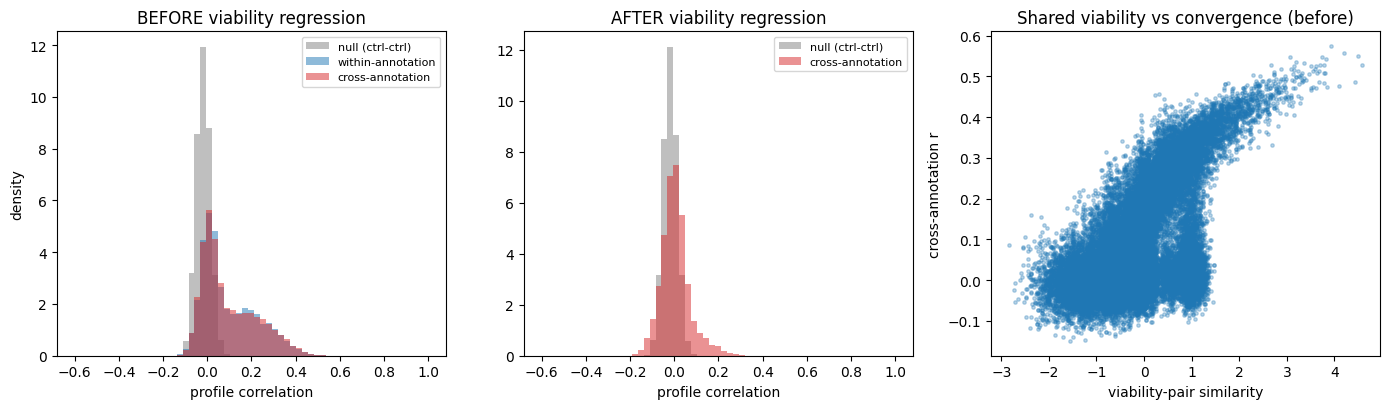

In [7]:
# Build the synthetic Replogle-schema dataset (with planted ground truth) and
# run the full pipeline. Expect ~80% of convergence attributed to viability, a
# surviving mechanism-specific residual, and PASS = True.
adata_syn = simulate(seed=0)
results = run_phase1(
    adata_syn,
    group_key="annotation_group",
    control_key="is_control",
    n_top_genes=2000,
)

## 4. Run on the real Replogle atlas

Colab has full internet, so the data-host limitation of restricted environments does not apply here - you can pull the file directly.

**Get the data.** From Figshare+ DOI `10.25452/figshare.plus.20029387`, use `K562_essential_normalized_bulk_01.h5ad` (the z-normalized essential-gene pseudobulk - a good first file; smaller than the genome-wide one).

**Load it** (next cell): mount Google Drive after putting the file there, or paste the Figshare download link to fetch it in-session.

**Prepare two `obs` columns** (the cell after): a boolean `is_control` (from the non-targeting label) and an `annotation_group`. The strict GO/CORUM/STRING orthogonality grouping is a later module, so this notebook uses a placeholder grouping just to run - the **H0 viability decomposition of overall convergence is valid regardless**, but the *cross-annotation* interpretation becomes meaningful only once the orthogonality filter is in place.

In [8]:
# ---------------------------------------------------------------------------
# Load the real Replogle atlas. Colab has full internet, so either:
#   (A) mount Google Drive (best for large files), or
#   (B) download directly from Figshare+ in this session.
# ---------------------------------------------------------------------------
import anndata as ad

# --- Option A: Google Drive (uncomment to use) -----------------------------
# from google.colab import drive
# drive.mount('/content/drive')
# INPUT_PATH = '/content/drive/MyDrive/replogle/K562_essential_normalized_bulk_01.h5ad'

# --- Option B: direct download from Figshare+ ------------------------------
# Open DOI 10.25452/figshare.plus.20029387, find
# 'K562_essential_normalized_bulk_01.h5ad', right-click its Download button and
# copy the link, then paste it below and run this cell.
REPLOGLE_URL = ""   # <- paste the Figshare download link here
INPUT_PATH   = ""   # <- or set a local / Drive path directly

if REPLOGLE_URL and not INPUT_PATH:
    INPUT_PATH = "K562_essential_normalized_bulk_01.h5ad"
    !wget -q -O "$INPUT_PATH" "$REPLOGLE_URL"

if INPUT_PATH:
    adata_real = ad.read_h5ad(INPUT_PATH)
    print(adata_real)
    print("\nobs columns:", list(adata_real.obs.columns))
    print(adata_real.obs.head())
else:
    print("Set REPLOGLE_URL or INPUT_PATH above to load the real atlas. Skipping for now.")

Set REPLOGLE_URL or INPUT_PATH above to load the real atlas. Skipping for now.


In [9]:
# ---------------------------------------------------------------------------
# Prepare obs keys and run Phase 1 on the real data.
# Inspect the obs printout above, then edit the two CONTROL_* settings to match.
# ---------------------------------------------------------------------------
if "adata_real" in globals():
    import numpy as np

    # --- 1. control flag --------------------------------------------------
    # Replogle marks non-targeting guides; build a boolean is_control from that.
    CONTROL_COLUMN = None             # e.g. 'gene' / the perturbation-id column; None -> use obs index
    CONTROL_VALUE  = "non-targeting"  # the NTC label (edit to match the file)

    labels = (adata_real.obs_names.astype(str) if CONTROL_COLUMN is None
              else adata_real.obs[CONTROL_COLUMN].astype(str))
    adata_real.obs["is_control"] = labels.str.contains(CONTROL_VALUE, case=False, regex=False)
    print("controls found:", int(adata_real.obs["is_control"].sum()))

    # --- 2. annotation grouping (PLACEHOLDER) -----------------------------
    # The GO/CORUM/STRING orthogonality filter is a later module. As a stopgap,
    # bucket perturbations into K pseudo-groups so the pipeline runs. With
    # placeholder groups the *cross-annotation* split is not yet a functional-
    # orthogonality claim, but the H0 viability decomposition stays valid.
    K = 8
    rng = np.random.default_rng(0)
    grp = rng.integers(0, K, size=adata_real.n_obs).astype(str)
    grp = np.where(adata_real.obs["is_control"].to_numpy(), "control", grp)
    adata_real.obs["annotation_group"] = grp

    # --- 3. gene-symbol aliases for the viability signature ---------------
    # Map legacy cell-cycle symbols to whatever form the file uses.
    ALIASES = {"MLF1IP": "CENPU", "FAM64A": "PIMREG", "HN1": "JPT1"}
    present = set(adata_real.var_names)

    def _resolve(sym):
        if sym in present:
            return sym
        alt = ALIASES.get(sym)
        if alt and alt in present:
            return alt
        for k, v in ALIASES.items():
            if v == sym and k in present:
                return k
        return sym

    VIABILITY_SIGNATURE = [_resolve(g) for g in VIABILITY_SIGNATURE]
    found = sum(g in present for g in VIABILITY_SIGNATURE)
    print(f"viability signature genes present: {found}/{len(VIABILITY_SIGNATURE)}")

    # --- 4. run -----------------------------------------------------------
    results_real = run_phase1(
        adata_real,
        group_key="annotation_group",
        control_key="is_control",
        n_top_genes=2000,
    )
else:
    print("adata_real not loaded - run the load cell above first.")

adata_real not loaded - run the load cell above first.


## 5. What's next / limitations

- **Annotation-orthogonality filter** - turns the placeholder grouping into a defensible "functionally unrelated" definition (GO semantic similarity + CORUM + STRING). The next module to build.
- **Mechanism attribution (H1/H3)** - score the saved residual on the ISR/ATF4 and NMD axes (decoupler) to start explaining the surviving convergence.
- **E-distance** - pertpy's single-cell distance is a planned sensitivity analysis alongside the pseudobulk-correlation convention used here.
- **Not causal** - this is decomposition/consistency, per the protocol's epistemic scope.

`results['residual']` holds the post-viability AnnData for the next phase.